In [2]:
# #import packages:

import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import time
from PIL import Image

import cellpose
from cellpose import models
from cellpose import io, models, train


import tifffile
import bigfish
import bigfish.stack as stack
import bigfish.plot as plot
import bigfish.multistack as multistack
import bigfish.detection as detection



from bigfish.stack import read_dv
from tifffile import imwrite, imread



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.4 
platform:       	linux 
python version: 	3.9.23 
torch version:  	2.7.1+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




#### Re-shape data for training input

In [ ]:

# Base directory
base_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell"

# Lists to store image stacks and paths
list_images = []
list_filenames = []
list_subdirs = []

# Traverse task directories and read .dv files
for subdir in sorted(os.listdir(base_dir)):
    subdir_path = os.path.join(base_dir, subdir)
    if os.path.isdir(subdir_path) and subdir.startswith("task-"):
        for file in os.listdir(subdir_path):
            if file.endswith(".dv"):
                dv_path = os.path.join(subdir_path, file)
                image_stack = read_dv(dv_path)
                list_images.append(image_stack)
                list_filenames.append(file.replace(".dv", ""))
                list_subdirs.append(subdir_path)  # Keep track of where to save
                break  # Only one .dv file per task

# Check and convert images
try:
    image_colors = np.array(list_images).astype(np.uint16)
except ValueError:
    print("Images have different shapes; keeping as list.")
    image_colors = [img.astype(np.uint16) for img in list_images]

# Process each image: save merged FITC + DAPI as 2-channel TIFF and sanity display
for i, image_name in enumerate(list_filenames):
    image = image_colors[i]
    print(f"Original image[{i}] shape: {image.shape}, dtype: {image.dtype}")
    
    save_dir = list_subdirs[i]
    task_number = os.path.basename(save_dir).replace("task-", "")
    tiff_filename = f"task-{task_number}-img.tiff"
    tiff_path = os.path.join(save_dir, tiff_filename)

    # Extract channels
    FITC_array = image[2]
    nuclei_array = image[3]

    # Max projections
    image_FITC = np.max(FITC_array, axis=0)
    image_nuclei = np.max(nuclei_array, axis=0)
    print(f"Max-projected FITC shape: {image_FITC.shape}, dtype: {image_FITC.dtype}")
    print(f"Max-projected nuclei shape: {image_nuclei.shape}, dtype: {image_nuclei.dtype}")

    # Normalize to uint8
    def normalize_uint8(channel):
        norm = (channel - channel.min()) / (np.ptp(channel) + 1e-8) * 255
        return norm.astype(np.uint8)

    fitc_uint8 = normalize_uint8(image_FITC)
    nuclei_uint8 = normalize_uint8(image_nuclei)
    blank = np.zeros_like(fitc_uint8, dtype=np.uint8)

    # Stack as RGB (H, W, 3): R=FITC, G=nuclei, B=blank
    rgb_image = np.stack([fitc_uint8, nuclei_uint8, blank], axis=-1)
    print(f"Stacked RGB image shape: {rgb_image.shape}, dtype: {rgb_image.dtype}")

    # Save as RGB TIFF
    imwrite(tiff_path, rgb_image)

    # === Sanity check: read back and display ===
    loaded_img = imread(tiff_path)
    print(f"Loaded TIFF image shape: {loaded_img.shape}, dtype: {loaded_img.dtype}")

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(loaded_img[:, :, 0], cmap="Greens")
    axs[0].set_title(f"task-{task_number} - FITC (membrane channel)")
    axs[0].axis("off")

    axs[1].imshow(loaded_img[:, :, 1], cmap="Blues")
    axs[1].set_title(f"task-{task_number} - DAPI (nuclei channel)")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()



[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-1/230713_Lp306_L4440_02_R3D.dv
→ Loaded shape: (4, 51, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-1/task-1-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


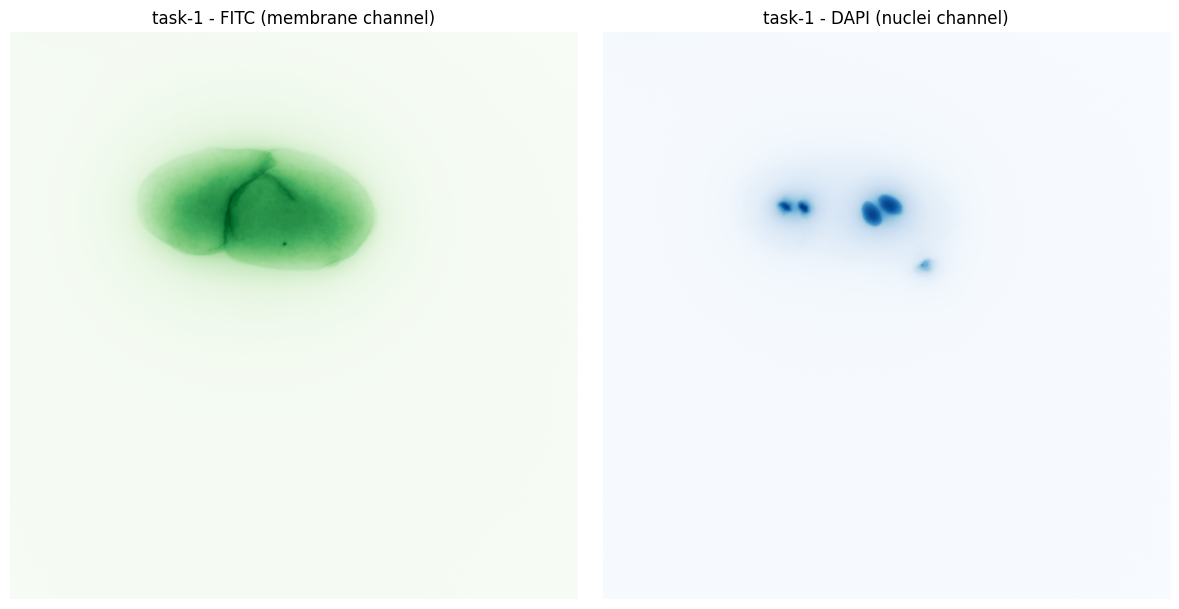


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-11/230713_Lp306_L4440_12_R3D.dv
→ Loaded shape: (4, 61, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-11/task-11-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


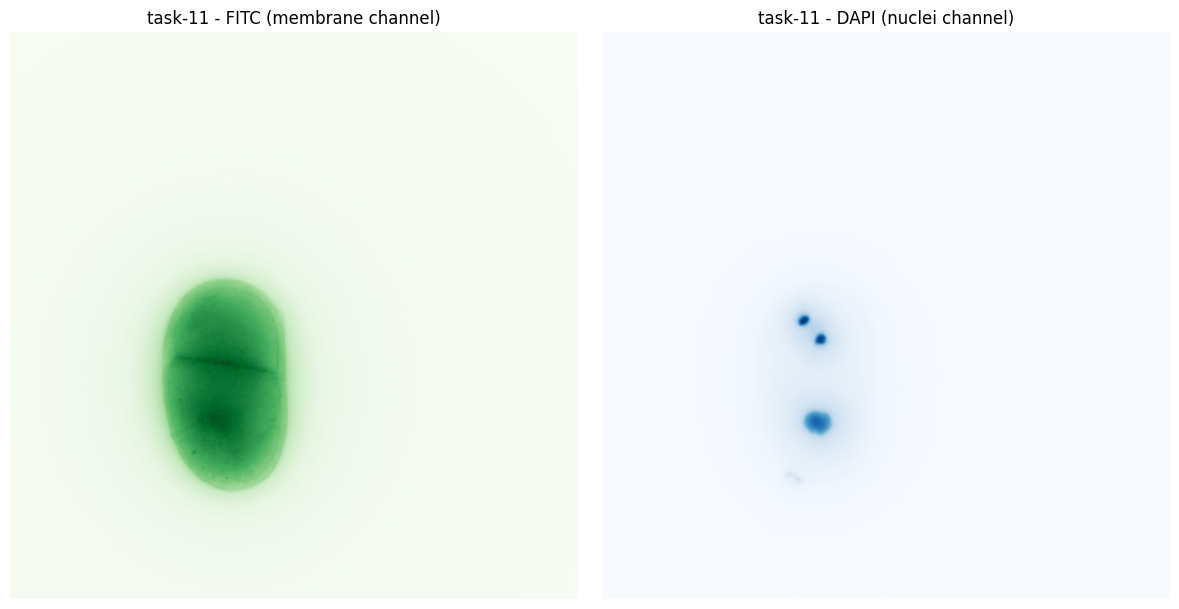


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-12/230713_Lp306_L4440_13_R3D.dv
→ Loaded shape: (4, 56, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-12/task-12-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


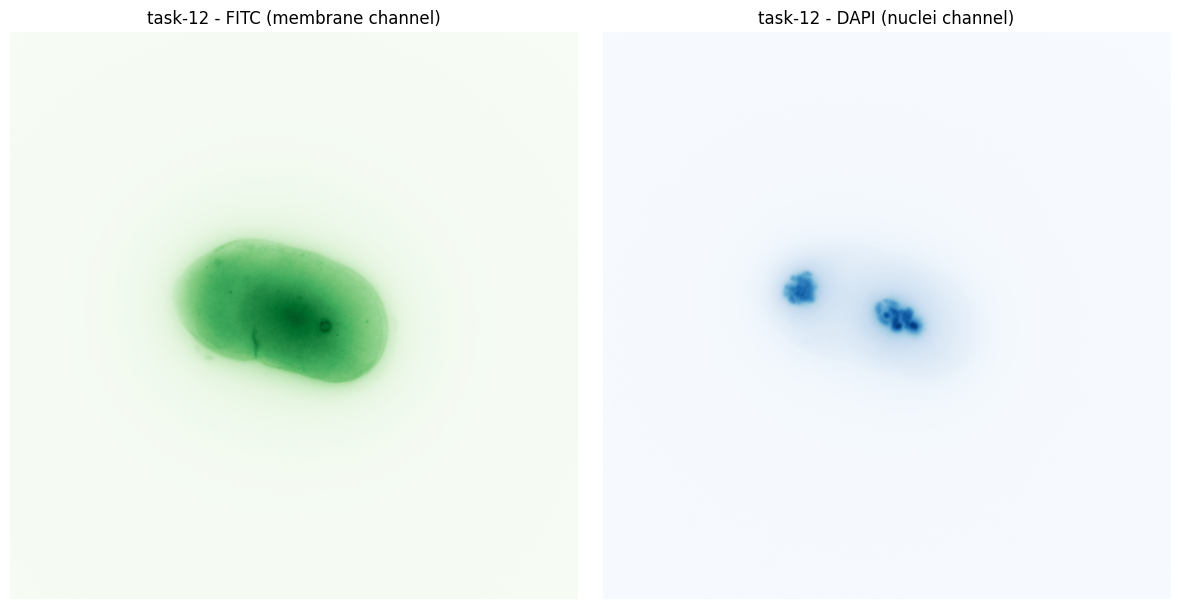


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-17/230828_L4440_RNAi_05_R3D.dv
→ Loaded shape: (4, 56, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-17/task-17-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


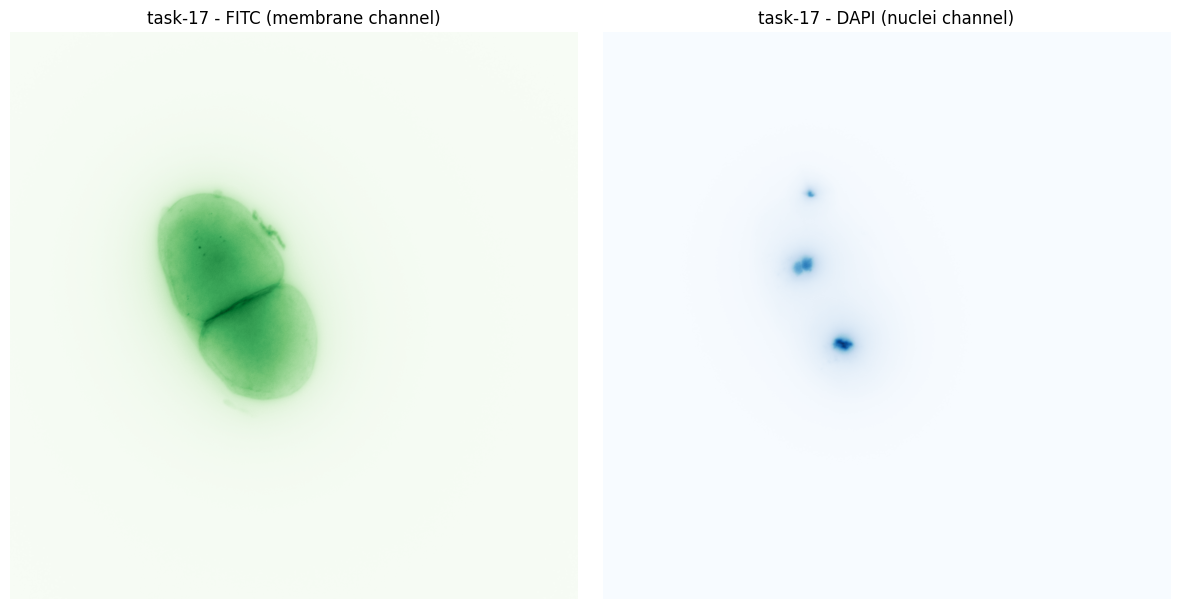


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-19/230828_L4440_RNAi_07_R3D.dv
→ Loaded shape: (4, 46, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-19/task-19-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


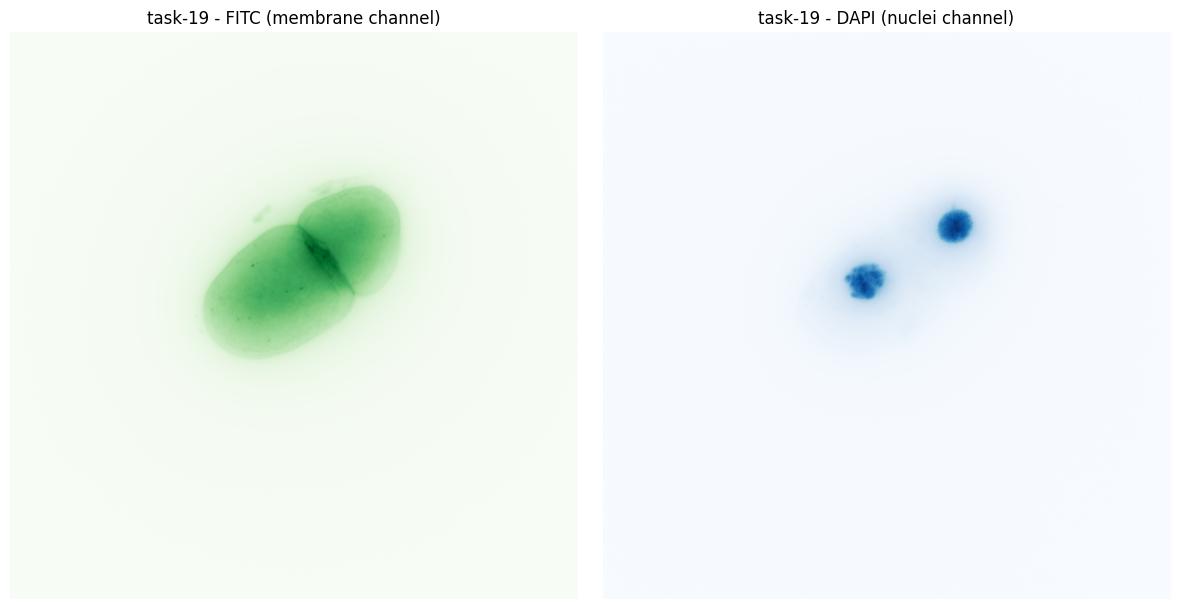


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-2/230713_Lp306_L4440_03_R3D.dv
→ Loaded shape: (4, 56, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-2/task-2-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


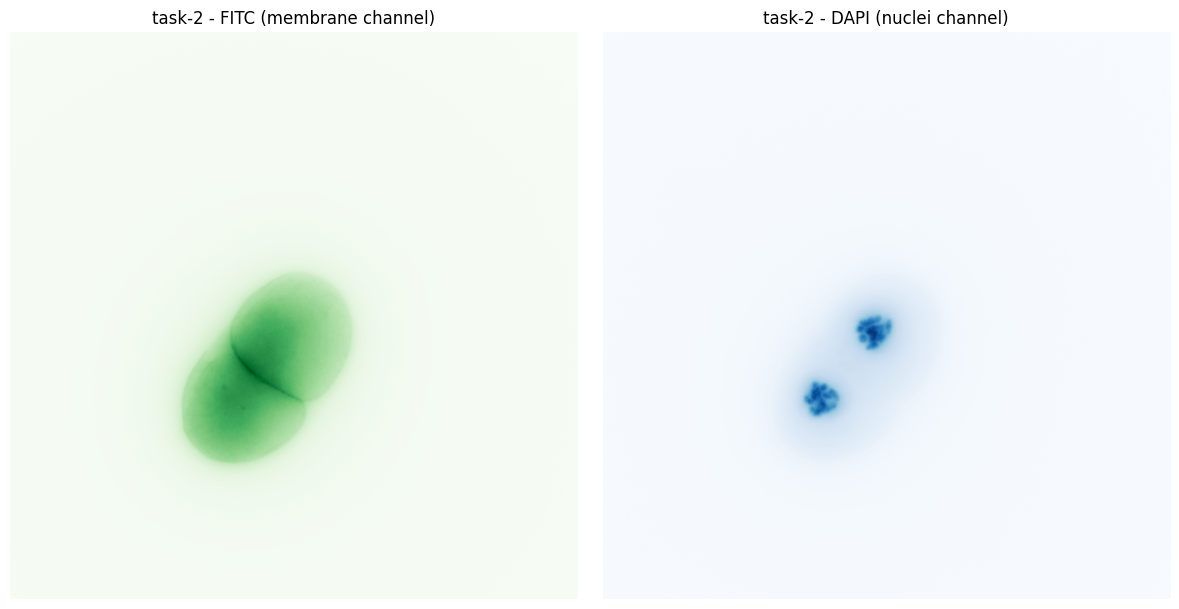


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-21/240122_LP306_L4440_01_R3D.dv
→ Loaded shape: (4, 79, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-21/task-21-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


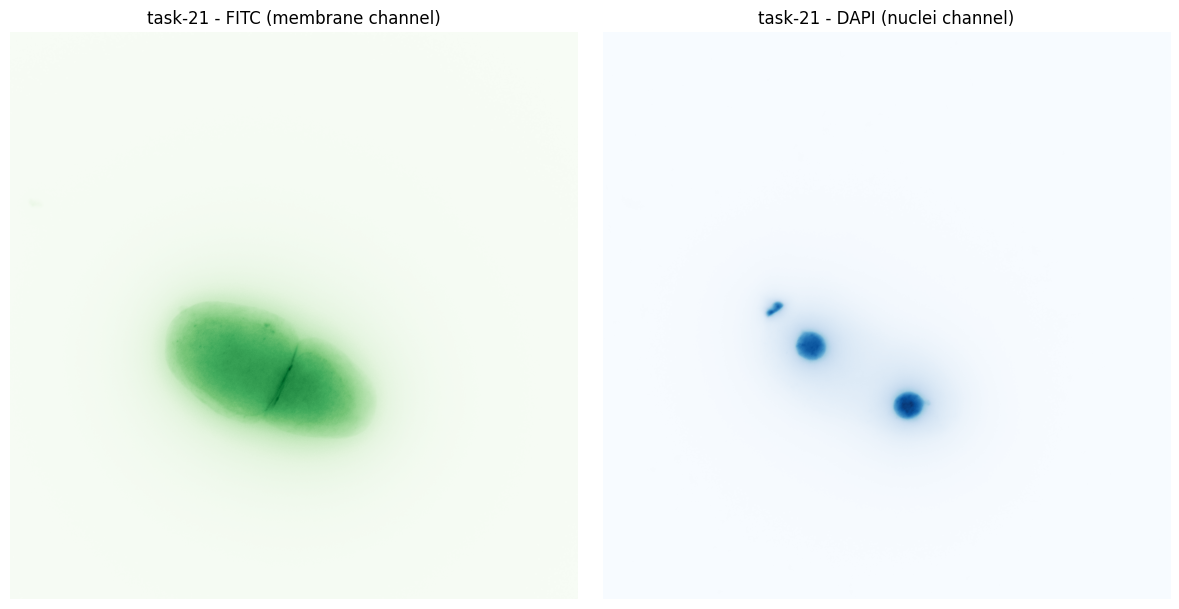


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-24/240122_LP306_L4440_04_R3D.dv
→ Loaded shape: (4, 70, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-24/task-24-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


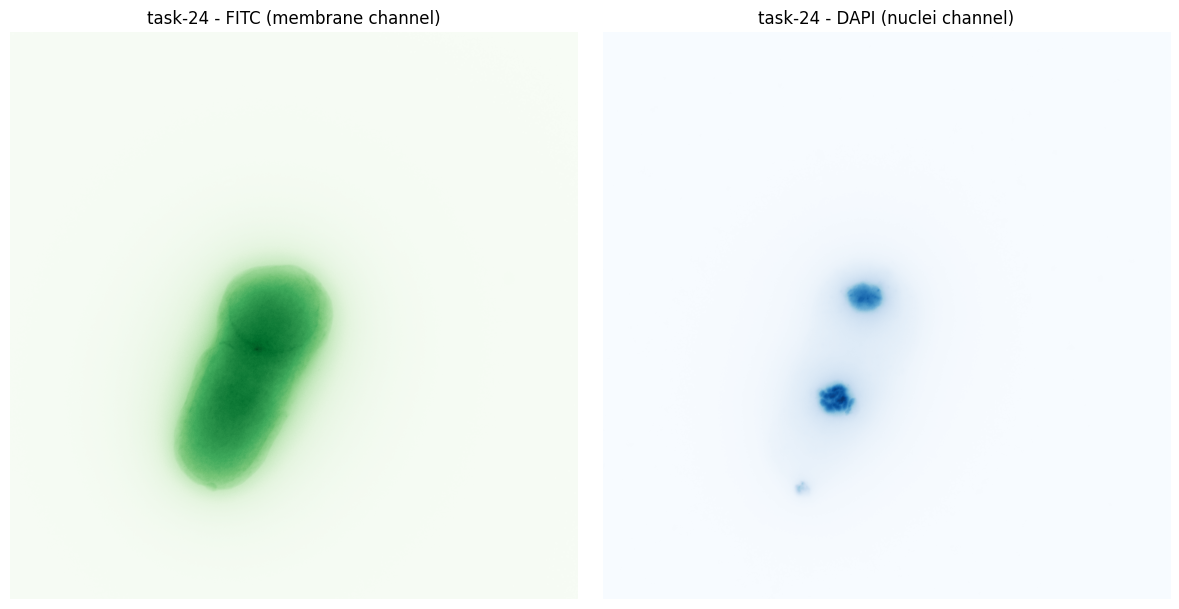


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-26/240122_LP306_L4440_06_R3D.dv
→ Loaded shape: (4, 80, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-26/task-26-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


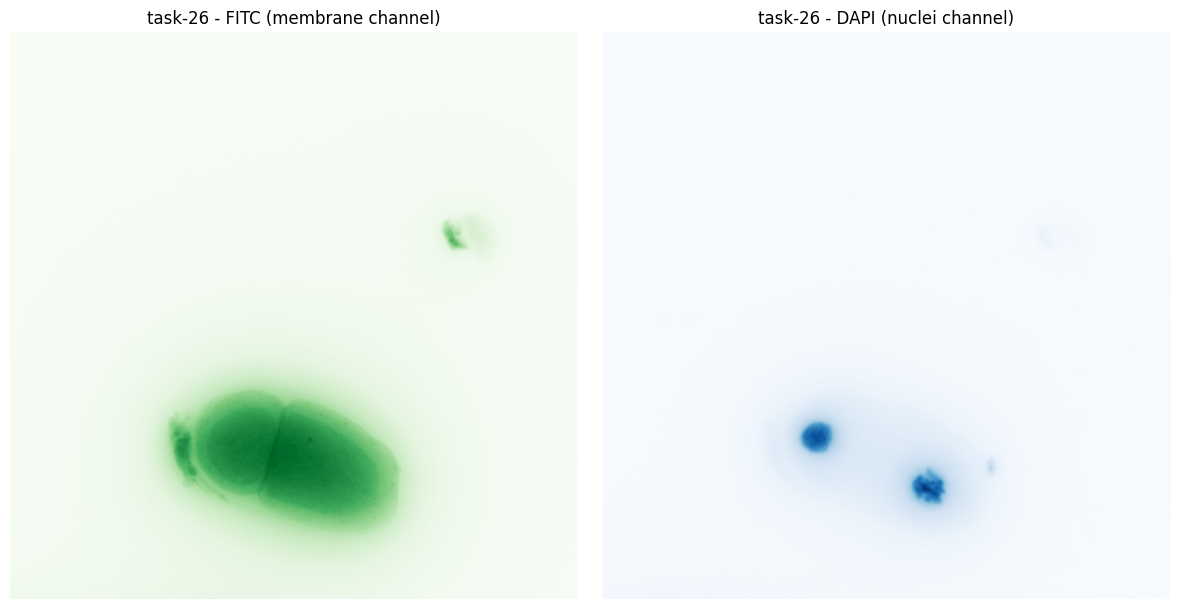


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-28/240122_LP306_L4440_08_R3D.dv
→ Loaded shape: (4, 75, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-28/task-28-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


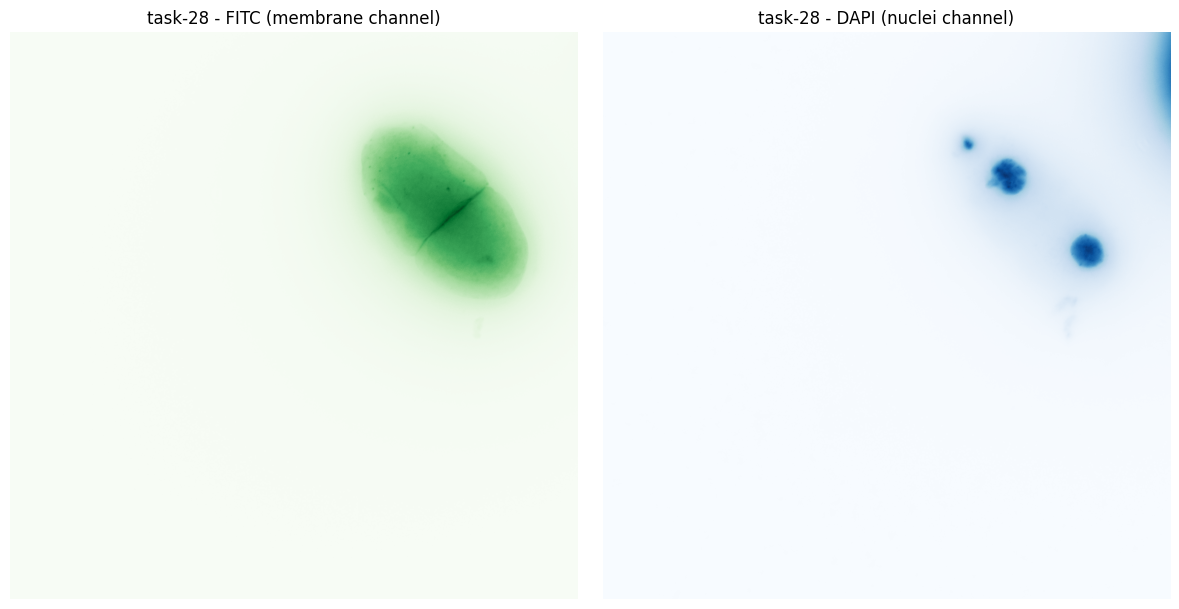


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-29/240122_LP306_L4440_09_R3D.dv
→ Loaded shape: (4, 70, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-29/task-29-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


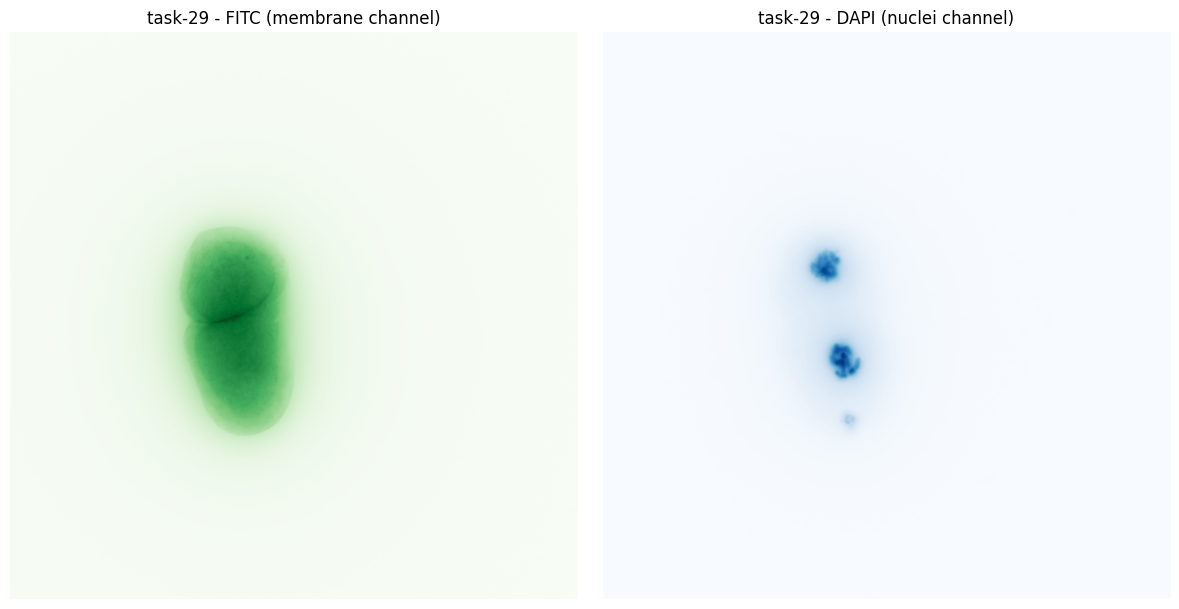


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-3/230713_Lp306_L4440_04_R3D.dv
→ Loaded shape: (4, 56, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-3/task-3-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


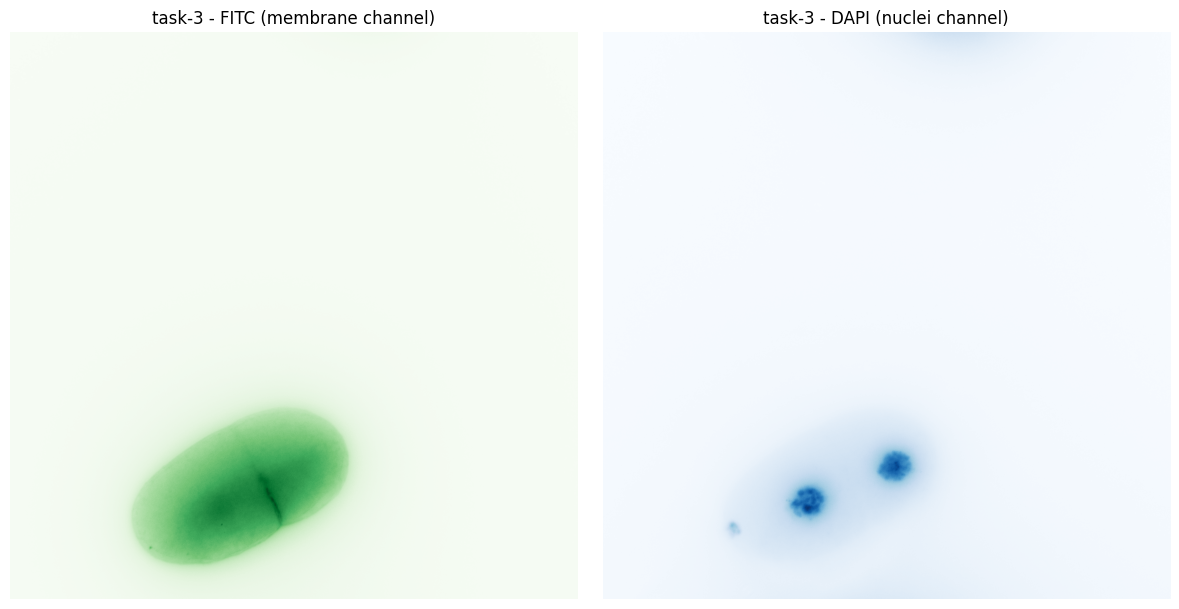


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-7/230713_Lp306_L4440_08_R3D.dv
→ Loaded shape: (4, 51, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-7/task-7-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


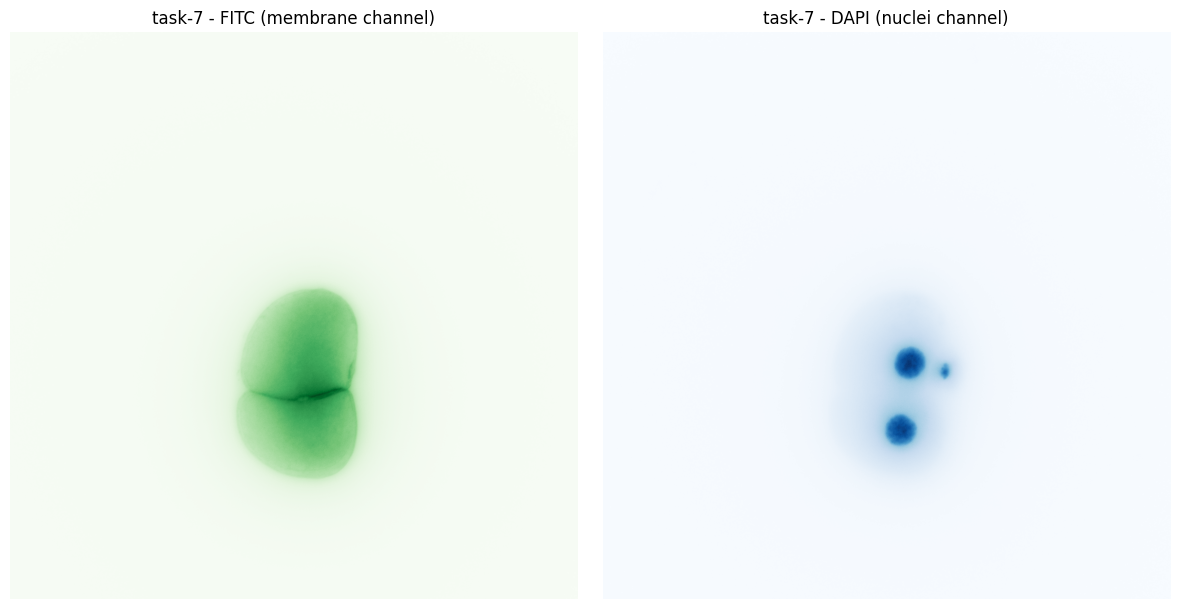


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-8/230713_Lp306_L4440_09_R3D.dv
→ Loaded shape: (4, 51, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-8/task-8-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


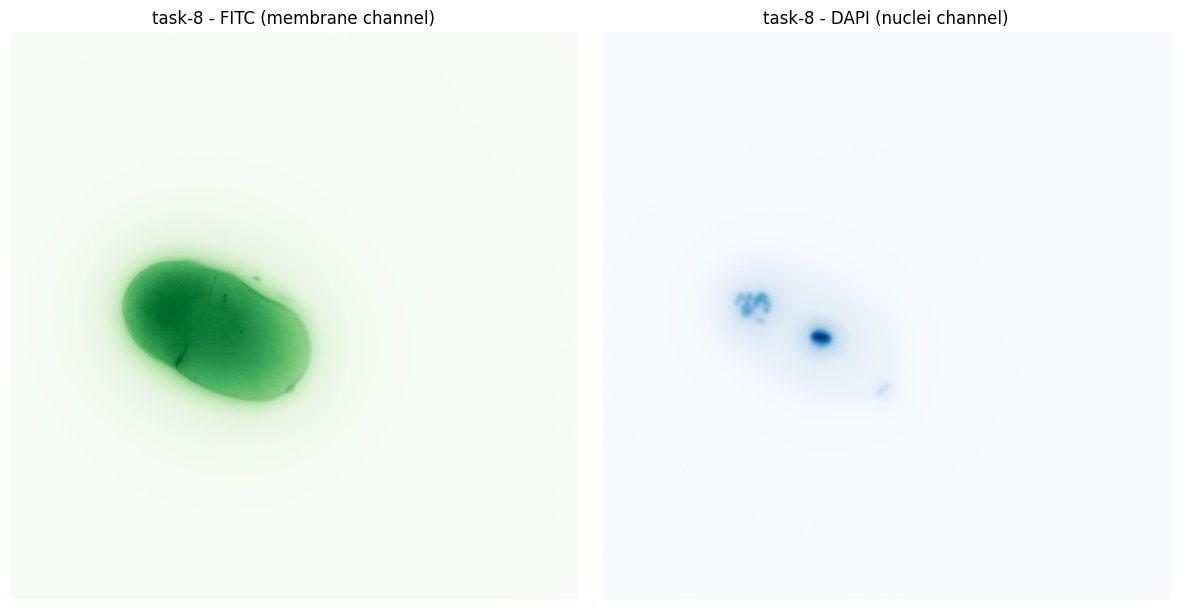


[✓] Found .dv: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-9/230713_Lp306_L4440_10_R3D.dv
→ Loaded shape: (4, 51, 1024, 1024), dtype: uint16
→ Stacked shape: (1024, 1024, 3), dtype: uint8
💾 Saved: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-9/task-9-img.tiff
Loaded TIFF image shape: (1024, 1024, 3), dtype: uint8


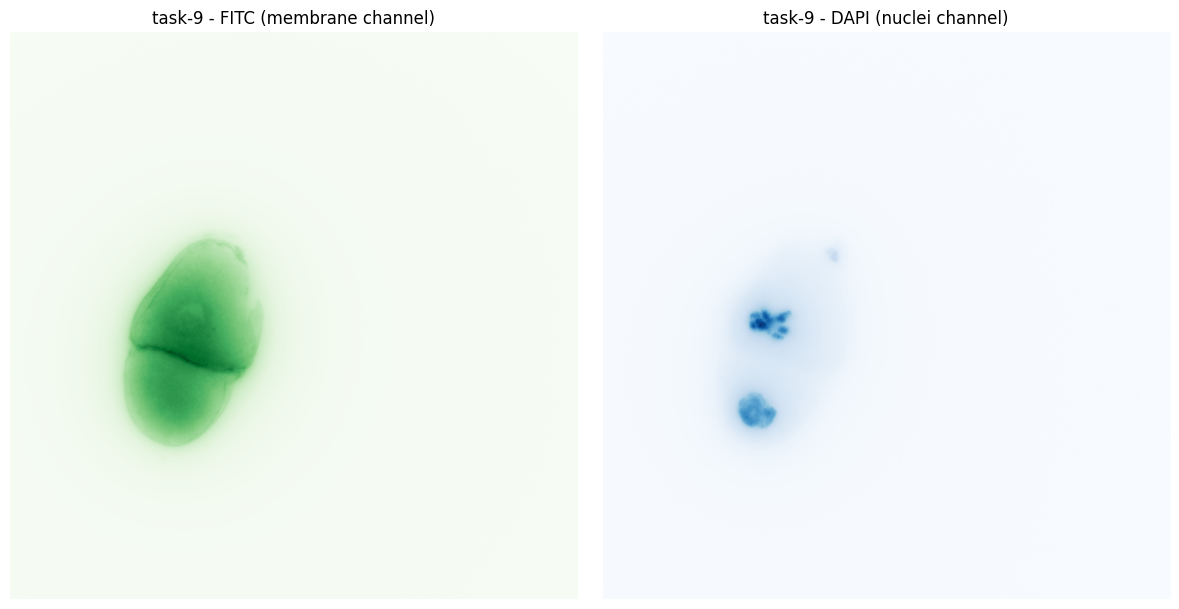

In [6]:
# Base directory
base_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell"

for subdir in sorted(os.listdir(base_dir)):
    subdir_path = os.path.join(base_dir, subdir)
    if not os.path.isdir(subdir_path) or not subdir.startswith("task-"):
        continue

    for file in os.listdir(subdir_path):
        if not file.endswith(".dv"):
            continue

        dv_path = os.path.join(subdir_path, file)
        print(f"\n[✓] Found .dv: {dv_path}")
        try:
            image_stack = read_dv(dv_path)
        except Exception as e:
            print(f"[!] Failed to load {dv_path}: {e}")
            continue

        print(f"→ Loaded shape: {image_stack.shape}, dtype: {image_stack.dtype}")

        # Extract task number and prepare output path
        task_number = subdir.replace("task-", "")
        tiff_filename = f"task-{task_number}-img.tiff"
        tiff_path = os.path.join(subdir_path, tiff_filename)

        try:
            FITC_array = image_stack[2]
            nuclei_array = image_stack[3]

            image_FITC = np.max(FITC_array, axis=0)  # max projection over z
            image_nuclei = np.max(nuclei_array, axis=0)

            def normalize_uint8(channel):
                norm = (channel - channel.min()) / (np.ptp(channel) + 1e-8) * 255
                return norm.astype(np.uint8)

            fitc_uint8 = normalize_uint8(image_FITC)
            nuclei_uint8 = normalize_uint8(image_nuclei)
            blank = np.zeros_like(fitc_uint8, dtype=np.uint8)

            rgb_image = np.stack([fitc_uint8, nuclei_uint8, blank], axis=-1)
            print(f"→ Stacked shape: {rgb_image.shape}, dtype: {rgb_image.dtype}")

            imwrite(tiff_path, rgb_image)
            print(f"💾 Saved: {tiff_path}")

            # === Sanity check: read back and display ===
            loaded_img = imread(tiff_path)
            print(f"Loaded TIFF image shape: {loaded_img.shape}, dtype: {loaded_img.dtype}")

            fig, axs = plt.subplots(1, 2, figsize=(12, 6))
            axs[0].imshow(loaded_img[:, :, 0], cmap="Greens")
            axs[0].set_title(f"task-{task_number} - FITC (membrane channel)")
            axs[0].axis("off")

            axs[1].imshow(loaded_img[:, :, 1], cmap="Blues")
            axs[1].set_title(f"task-{task_number} - DAPI (nuclei channel)")
            axs[1].axis("off")

            plt.tight_layout()
            plt.show()

        except IndexError:
            print(f"[!] Missing expected channels in {dv_path}")
        except Exception as e:
            print(f"[!] Processing error: {e}")



task-1 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-1 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-1 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


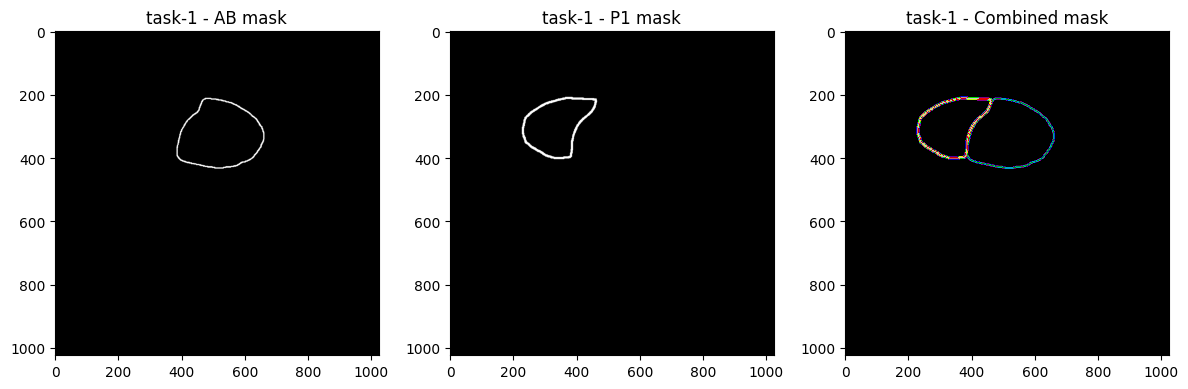

/tmp/ipykernel_2404456/1775810064.py:57: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave(save_mask_path, combined_mask)


Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-1/task-1-masks.tiff
task-12 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-12 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-12 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


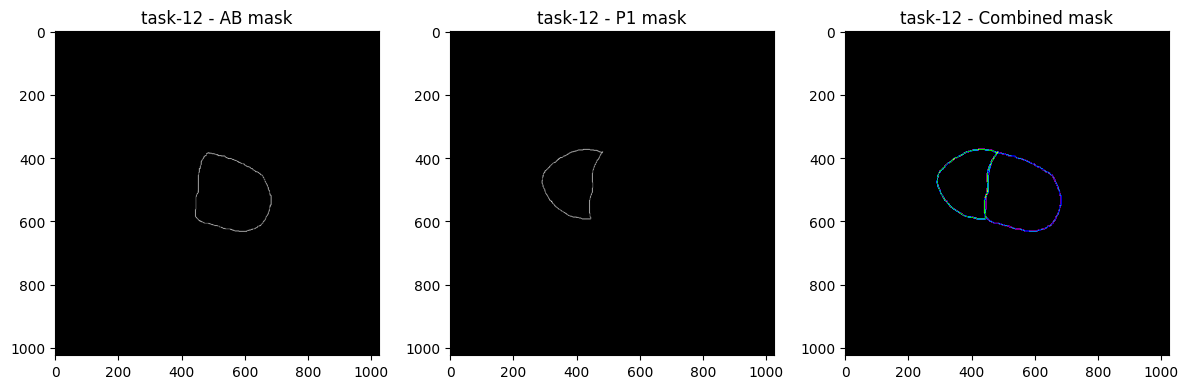

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-12/task-12-masks.tiff
task-29 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-29 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-29 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


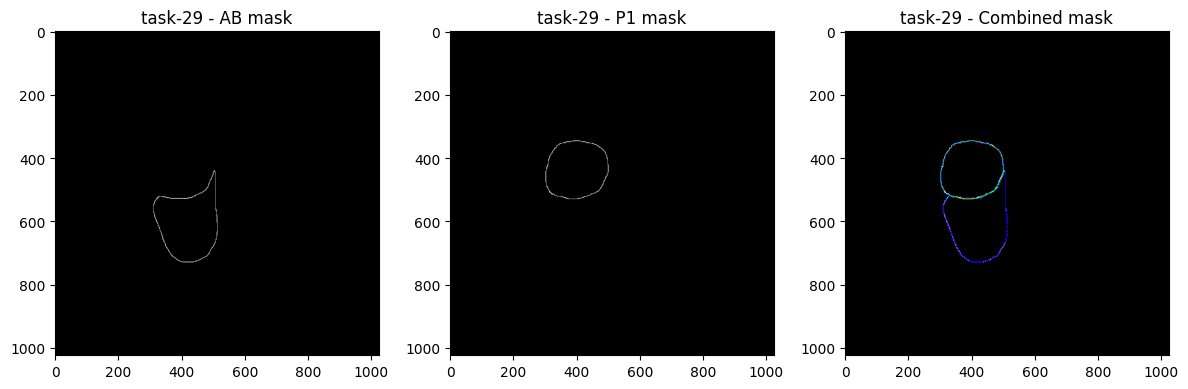

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-29/task-29-masks.tiff
task-8 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-8 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-8 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


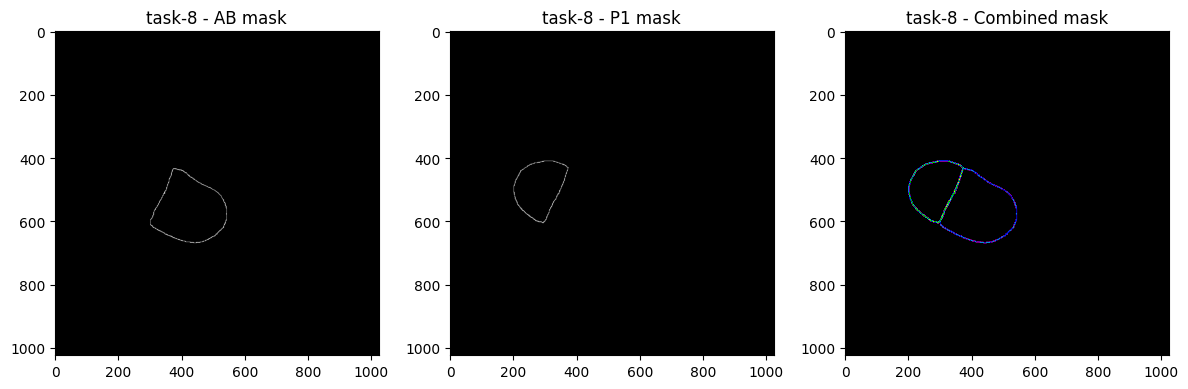

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-8/task-8-masks.tiff
task-2 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-2 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-2 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


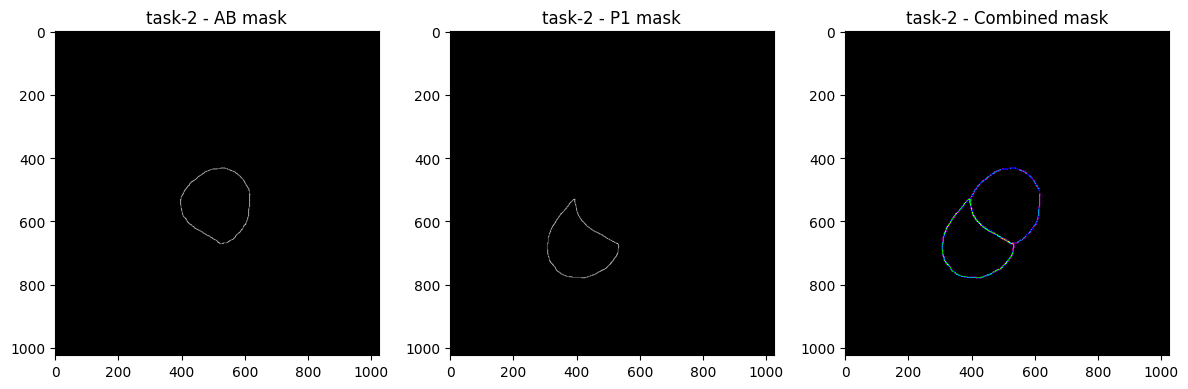

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-2/task-2-masks.tiff
task-11 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-11 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-11 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


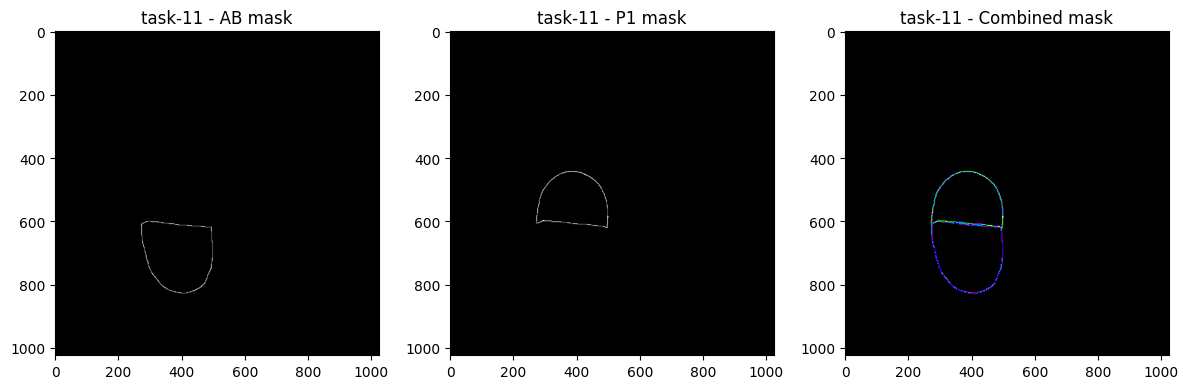

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-11/task-11-masks.tiff
task-24 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-24 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-24 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


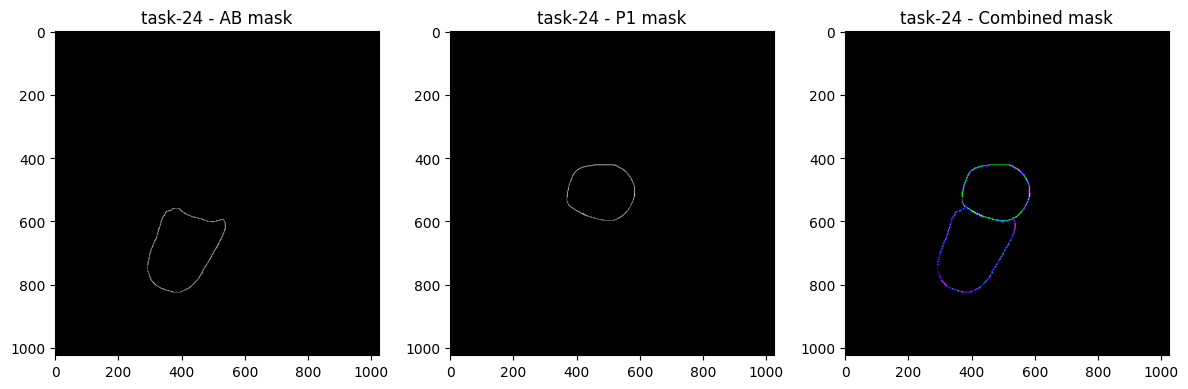

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-24/task-24-masks.tiff
task-26 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-26 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-26 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


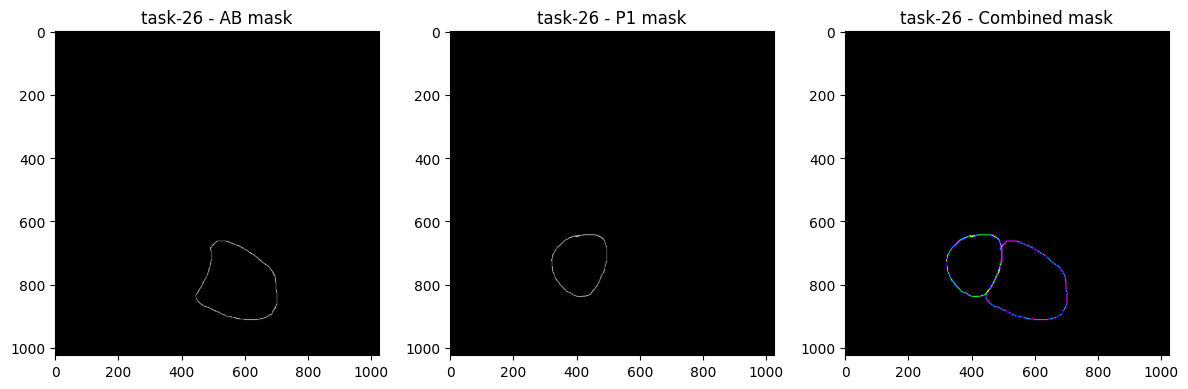

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-26/task-26-masks.tiff
task-7 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-7 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-7 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


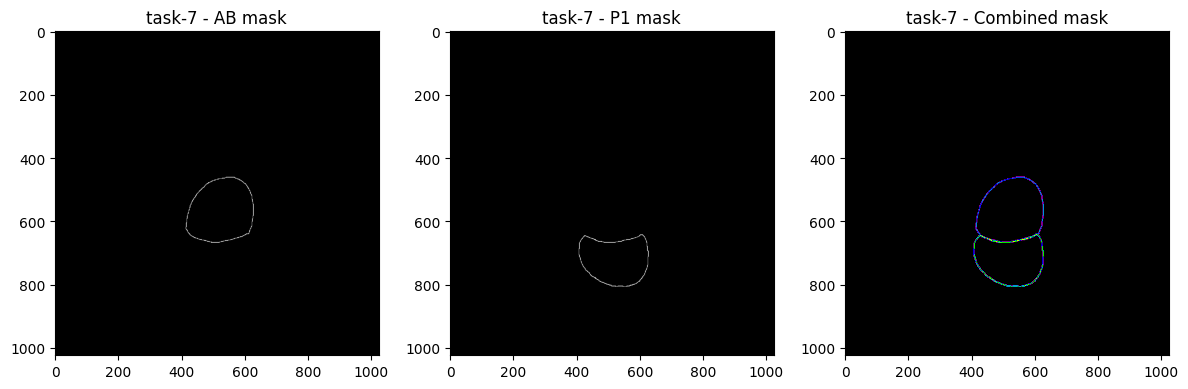

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-7/task-7-masks.tiff
task-21 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-21 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-21 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


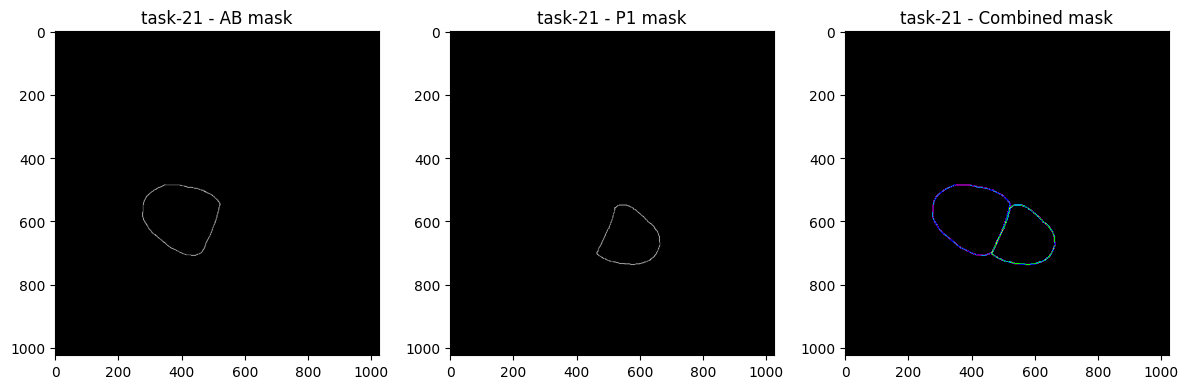

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-21/task-21-masks.tiff
task-19 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-19 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-19 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


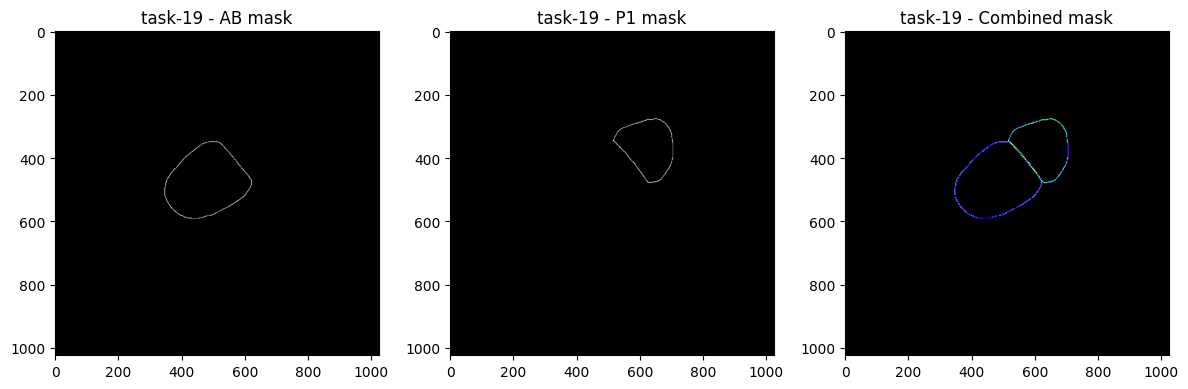

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-19/task-19-masks.tiff
task-17 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-17 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-17 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


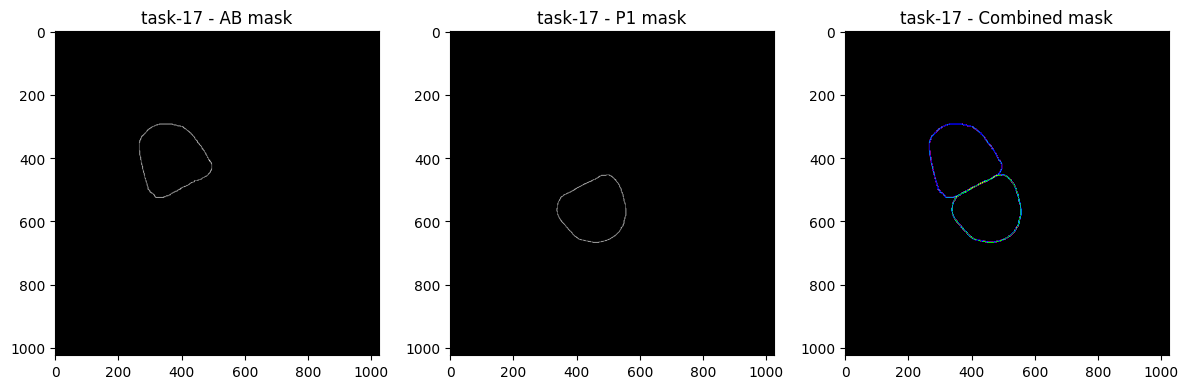

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-17/task-17-masks.tiff
task-28 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-28 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-28 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


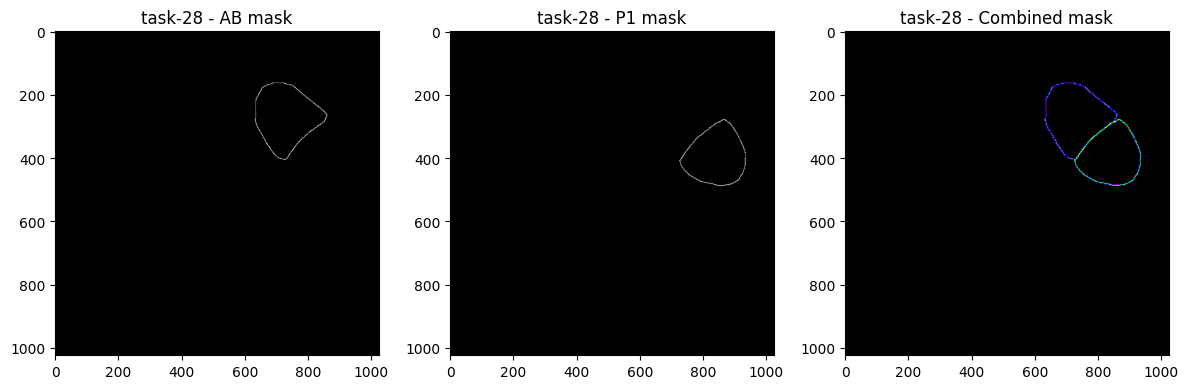

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-28/task-28-masks.tiff
task-3 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-3 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-3 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


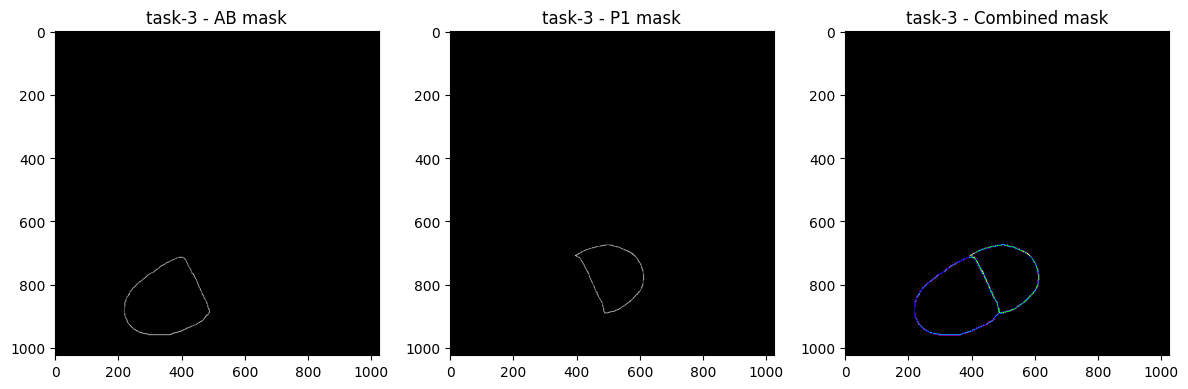

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-3/task-3-masks.tiff
task-9 AB mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-9 P1 mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1]
task-9 Combined mask: shape=(1024, 1024), dtype=uint16, unique values=[0 1 2]


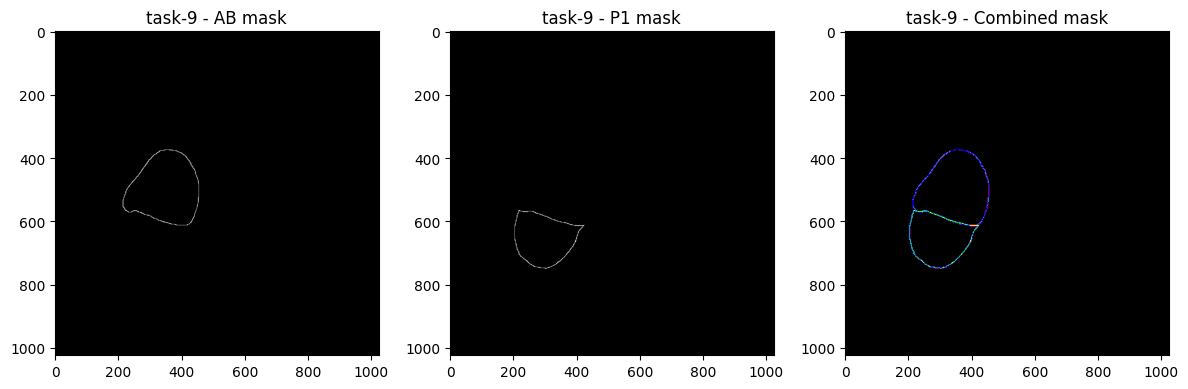

Saved combined mask: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/task-9/task-9-masks.tiff


In [8]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tifffile import imsave  # pip install tifffile

def load_binary_mask(path):
    mask = Image.open(path).convert("L")
    arr = np.array(mask)
    binary = (arr > 127).astype(np.uint16)
    return binary

# Base directory
base_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell"

# Process each task subdirectory
for task_name in os.listdir(base_dir):
    task_path = os.path.join(base_dir, task_name)
    if not os.path.isdir(task_path) or not task_name.startswith("task-"):
        continue

    ab_mask_path = os.path.join(task_path, f"{task_name}-AB-masks.png")
    p1_mask_path = os.path.join(task_path, f"{task_name}-P1-masks.png")

    if os.path.exists(ab_mask_path) and os.path.exists(p1_mask_path):
        ab_mask = load_binary_mask(ab_mask_path)
        p1_mask = load_binary_mask(p1_mask_path)

        combined_mask = np.zeros_like(ab_mask, dtype=np.uint16)
        combined_mask[ab_mask == 1] = 1
        combined_mask[p1_mask == 1] = 2

        # Print mask info for debugging / Cellpose checks
        print(f"{task_name} AB mask: shape={ab_mask.shape}, dtype={ab_mask.dtype}, unique values={np.unique(ab_mask)}")
        print(f"{task_name} P1 mask: shape={p1_mask.shape}, dtype={p1_mask.dtype}, unique values={np.unique(p1_mask)}")
        print(f"{task_name} Combined mask: shape={combined_mask.shape}, dtype={combined_mask.dtype}, unique values={np.unique(combined_mask)}")

        # Sanity check visualization
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(ab_mask, cmap='gray')
        plt.title(f"{task_name} - AB mask")

        plt.subplot(1, 3, 2)
        plt.imshow(p1_mask, cmap='gray')
        plt.title(f"{task_name} - P1 mask")

        plt.subplot(1, 3, 3)
        plt.imshow(combined_mask, cmap='nipy_spectral')
        plt.title(f"{task_name} - Combined mask")

        plt.tight_layout()
        plt.show()

        # Save combined mask with task prefix in filename
        save_mask_path = os.path.join(task_path, f"{task_name}-masks.tiff")
        imsave(save_mask_path, combined_mask)
        print(f"Saved combined mask: {save_mask_path}")

    else:
        print(f"Missing AB or P1 mask in {task_name}")


#### Split dataset in 80% for training and 20% for testing

In [9]:
import os
import random
import shutil

# Base and output directories
base_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell"
train_dir = os.path.join(base_dir, "train_dir")
test_dir = os.path.join(base_dir, "test_dir")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get all task subdirectories
task_subdirs = [d for d in os.listdir(base_dir) if d.startswith("task-") and os.path.isdir(os.path.join(base_dir, d))]

# Shuffle and split
random.seed(42)
random.shuffle(task_subdirs)
split_index = int(len(task_subdirs) * 0.6)
train_tasks = task_subdirs[:split_index]
test_tasks = task_subdirs[split_index:]

print(f"Copying {len(train_tasks)} tasks to train_dir, {len(test_tasks)} to test_dir...")

def copy_flat(task_list, destination_dir):
    for task in task_list:
        task_path = os.path.join(base_dir, task)
        img_file = f"{task}-img.tiff"
        masks_file = f"{task}-masks.tiff"

        src_img = os.path.join(task_path, img_file)
        src_masks = os.path.join(task_path, masks_file)

        dst_img = os.path.join(destination_dir, img_file)
        dst_masks = os.path.join(destination_dir, masks_file)

        if os.path.exists(src_img):
            shutil.copy2(src_img, dst_img)
        else:
            print(f"Warning: {img_file} not found in {task_path}")

        if os.path.exists(src_masks):
            shutil.copy2(src_masks, dst_masks)
        else:
            print(f"Warning: {masks_file} not found in {task_path}")

# Execute copying
copy_flat(train_tasks, train_dir)
copy_flat(test_tasks, test_dir)

print("Done.")




Copying 9 tasks to train_dir, 6 to test_dir...
Done.


In [10]:
# #Sanity check on files shape

def check_dir_shapes(image_dir, label_suffix="-masks.tiff", image_suffix="-img.tiff"):
    print(f"\nChecking directory: {image_dir}")
    for filename in sorted(os.listdir(image_dir)):
        if filename.endswith(image_suffix):
            image_path = os.path.join(image_dir, filename)
            mask_path = image_path.replace(image_suffix, label_suffix)

            # Load image
            image = imread(image_path)
            print(f"\nImage: {filename}")
            print(f"  shape: {image.shape}, dtype: {image.dtype}")
            print(f"  min: {image.min()}, max: {image.max()}")
            if image.ndim == 3:
                for i in range(image.shape[2]):
                    print(f"  channel {i} min/max: {image[...,i].min()}/{image[...,i].max()}")

            # Load corresponding mask if it exists
            if os.path.exists(mask_path):
                mask = imread(mask_path)
                print(f"  Mask: {os.path.basename(mask_path)}")
                print(f"    shape: {mask.shape}, dtype: {mask.dtype}")
                print(f"    unique values: {np.unique(mask)}")
            else:
                print("  No corresponding mask found.")

# Paths
train_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/train_dir"
test_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/test_dir"

# Run checks
check_dir_shapes(train_dir)
check_dir_shapes(test_dir)



Checking directory: /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/train_dir

Image: task-11-img.tiff
  shape: (1024, 1024, 3), dtype: uint8
  min: 0, max: 254
  channel 0 min/max: 0/254
  channel 1 min/max: 0/254
  channel 2 min/max: 0/0
  Mask: task-11-masks.tiff
    shape: (1024, 1024), dtype: uint16
    unique values: [0 1 2]

Image: task-21-img.tiff
  shape: (1024, 1024, 3), dtype: uint8
  min: 0, max: 254
  channel 0 min/max: 0/254
  channel 1 min/max: 0/254
  channel 2 min/max: 0/0
  Mask: task-21-masks.tiff
    shape: (1024, 1024), dtype: uint16
    unique values: [0 1 2]

Image: task-24-img.tiff
  shape: (1024, 1024, 3), dtype: uint8
  min: 0, max: 254
  channel 0 min/max: 0/254
  channel 1 min/max: 0/254
  channel 2 min/max: 0/0
  Mask: task-24-masks.tiff
    shape: (1024, 1024), dtype: uint16
    unique values: [0 1 2]

Image: task-26-img.tiff
  shape: (1024, 1024, 3), dtype: uint8
  min: 0, max: 254
  channel 0 min/max: 0/254
  channel 1 min/max: 0/2

#### train and test model

In [11]:
# Train cellpose model

# Set paths
train_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/train_dir"
test_dir = "/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/test_dir"

io.logger_setup()

output = io.load_train_test_data(train_dir, test_dir, image_filter="-img",
                                mask_filter="-masks", look_one_level_down=False)
images, labels, image_names, test_images, test_labels, image_names_test = output

model = models.CellposeModel(gpu=True) # if you want to continue fine-tuning from your trained model add: , pretrained_model="/your/path/to/my_new_model")

model_path, train_losses, test_losses = train.train_seg(model.net,
                            train_data=images, train_labels=labels,
                            test_data=test_images, test_labels=test_labels,
                            weight_decay=0.1, learning_rate=1e-5,
                            n_epochs=80, model_name="my_new_model6",
                                                       min_train_masks=1)


# Save train and test lost data
np.save("test_losses.npy", test_losses)
np.save("train_losses.npy", train_losses)

2025-07-01 17:05:09,438 [INFO] WRITING LOG OUTPUT TO /home/naly@colostate.edu/.cellpose/run.log
2025-07-01 17:05:09,439 [INFO] 
cellpose version: 	4.0.4 
platform:       	linux 
python version: 	3.9.23 
torch version:  	2.7.1+cu126
2025-07-01 17:05:09,464 [INFO] not all flows are present, running flow generation for all images
2025-07-01 17:05:09,499 [INFO] 9 / 9 images in /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/train_dir folder have labels
2025-07-01 17:05:09,512 [INFO] not all flows are present, running flow generation for all images
2025-07-01 17:05:09,549 [INFO] 6 / 6 images in /pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_cell-labels/2-cell/test_dir folder have labels
2025-07-01 17:05:10,070 [INFO] ** TORCH CUDA version installed and working. **
2025-07-01 17:05:10,072 [INFO] >>>> using GPU (CUDA)
2025-07-01 17:05:11,729 [INFO] >>>> loading model /home/naly@colostate.edu/.cellpose/models/cpsam
2025-07-01 17:05:15,904 [INFO] computing flows for la

100%|██████████| 9/9 [00:01<00:00,  5.97it/s]

2025-07-01 17:05:17,445 [INFO] computing flows for labels



100%|██████████| 6/6 [00:00<00:00,  6.40it/s]

2025-07-01 17:05:18,400 [INFO] >>> computing diameters



100%|██████████| 6/6 [00:00<00:00, 724.72it/s]

2025-07-01 17:05:18,435 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2025-07-01 17:05:18,951 [INFO] >>> n_epochs=80, n_train=9, n_test=6
2025-07-01 17:05:18,953 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2025-07-01 17:05:18,957 [INFO] >>> saving model to /projects/naly@colostate.edu/bigfish/ce-bigfish/01_notebooks/models/my_new_model6
2025-07-01 17:05:21,203 [INFO] 0, train_loss=0.2808, test_loss=1.4928, LR=0.000000, time 2.25s
2025-07-01 17:05:26,786 [INFO] 5, train_loss=0.1263, test_loss=0.1755, LR=0.000006, time 7.83s
2025-07-01 17:05:32,302 [INFO] 10, train_loss=0.0373, test_loss=0.0599, LR=0.000010, time 13.35s
2025-07-01 17:05:42,976 [INFO] 20, train_loss=0.0240, test_loss=0.0523, LR=0.000010, time 24.02s
2025-07-01 17:05:53,659 [INFO] 30, train_loss=0.0199, test_loss=0.0516, LR=0.000010, time 34.70s
2025-07-01 17:06:04,384 [INFO] 40, train_loss=0.0239, test_loss=0.0499, LR=0.000010, time 45.43s
2025-07-01 17:06:15,097 [INFO] 50, train_loss=0.0226, test_loss=0.0483, LR=0.000010, time 56.14s
2025-07-01 17:06:25,804 [INFO] 60, tra

#### Sanity checks!

2025-07-01 17:15:04,154 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2025-07-01 17:15:04,822 [INFO] No cell pixels found.


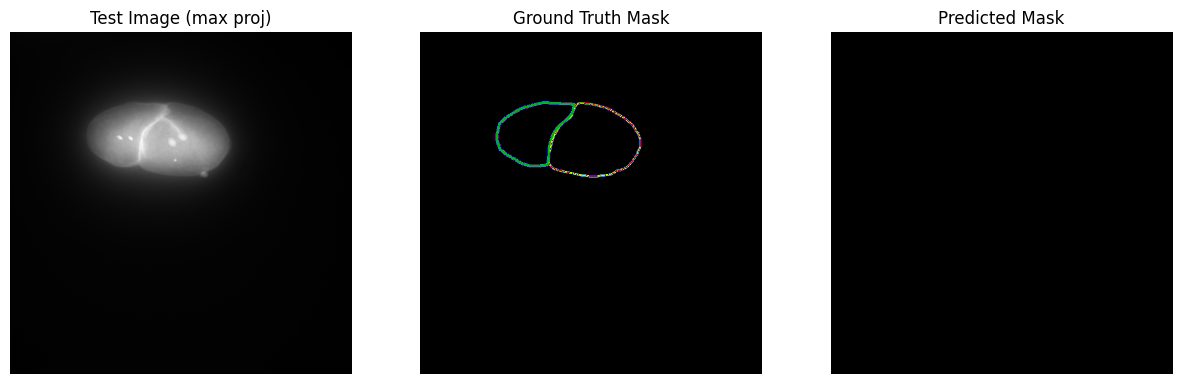

Unique predicted mask values: [0]
2025-07-01 17:15:05,108 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2025-07-01 17:15:05,719 [INFO] No cell pixels found.


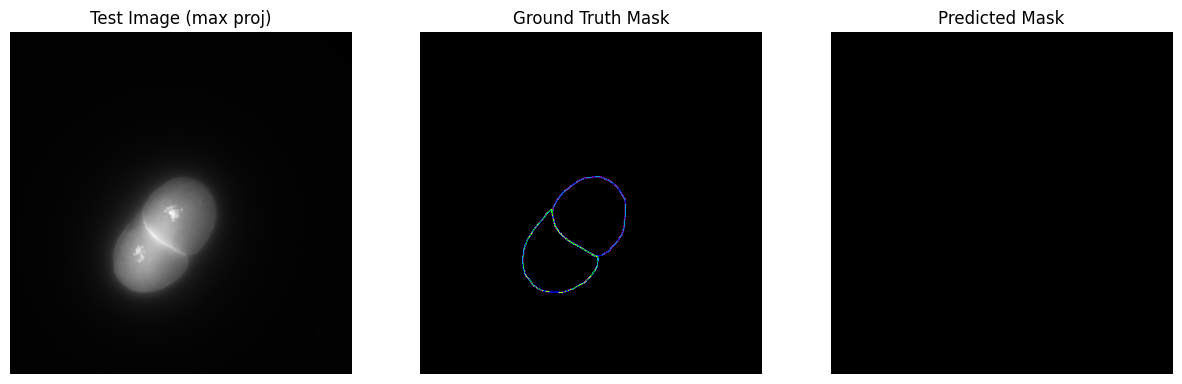

Unique predicted mask values: [0]
2025-07-01 17:15:06,003 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2025-07-01 17:15:06,612 [INFO] No cell pixels found.


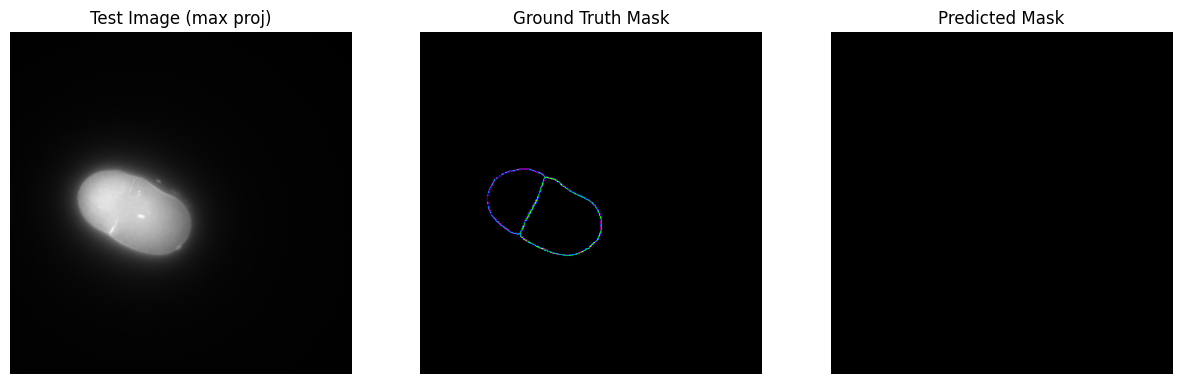

Unique predicted mask values: [0]
2025-07-01 17:15:06,896 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2025-07-01 17:15:07,506 [INFO] No cell pixels found.


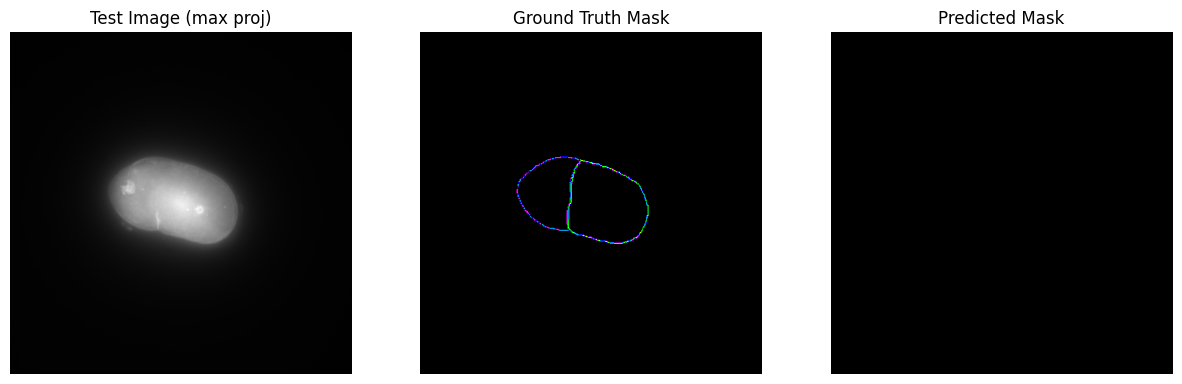

Unique predicted mask values: [0]
2025-07-01 17:15:07,793 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2025-07-01 17:15:08,402 [INFO] No cell pixels found.


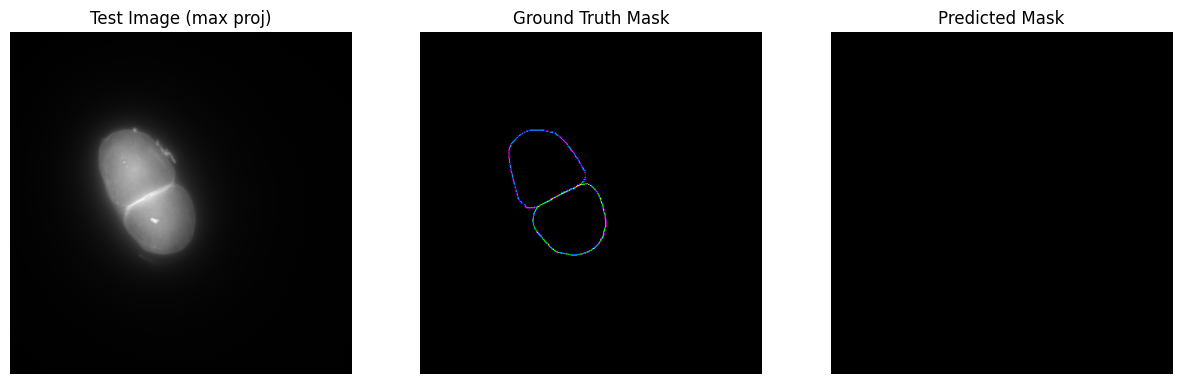

Unique predicted mask values: [0]


In [26]:
for i in range(min(5, len(test_images))):
    image = test_images[i]
    
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)
    image = (image * 255).astype(np.uint8)
    true_mask = test_labels[i]

    masks_pred, flows, styles = model.eval(image, channels=[0, 1])

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image.max(axis=2), cmap='gray')
    plt.title("Test Image (max proj)")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(true_mask, cmap='nipy_spectral')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(masks_pred, cmap='nipy_spectral')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()
    


[1.49275374 0.         0.         0.         0.         0.17545885
 0.         0.         0.         0.         0.05993157 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.05228418 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.05157231 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.04993149 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.04827467 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.04686933 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.04470695 0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
[0.28084696 0.04474617 0.1527214  0.10857789 0.27614768 0.04950241
 0.02070836 0.07359097 0.04020149 0.02152178 0.0306538  0.00881029
 0.02574621 0.0323507  0.03570359 0.00852707 0.02817808 0.02919398


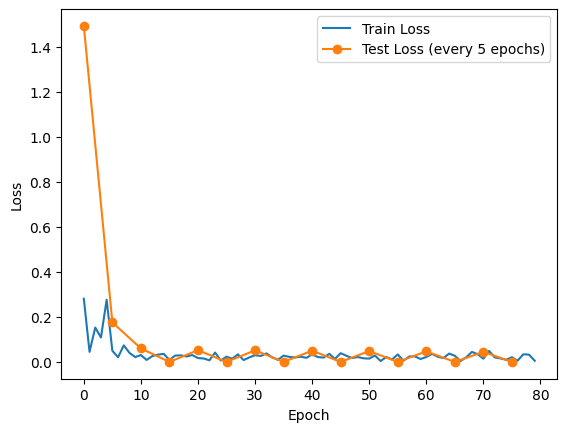

In [36]:
# Example: suppose test losses are computed every 5 epochs
import matplotlib.pyplot as plt
from datetime import datetime
import os


print(test_losses)
print(train_losses)

# Example: suppose test losses are computed every 5 epochs
test_interval = 5
epochs = np.arange(len(train_losses))
test_epochs = epochs[::test_interval]
test_loss_values = test_losses[::test_interval]

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(test_epochs, test_loss_values, 'o-', label="Test Loss (every 5 epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Save with current date prefix
models_dir = "/projects/naly@colostate.edu/bigfish/ce-bigfish/01_notebooks/models"
date_str = datetime.now().strftime("%Y-%m-%d")
filename = f"{date_str}_model_performance.png"
save_path = os.path.join(models_dir, filename)

plt.savefig(save_path)
print(f"Saved plot to {save_path}")

plt.show()
plt.close()


#### Use model on unseen data